# Lecture 13: Transformers, Attention, and State-of-the-Art Models with HuggingFace

How to "read" this lecture notebook
<details>
<summary>click to expand</summary>

As you go through this notebook (or any notebook for this class), you will encounter new concepts and Python code that implements them, just like you would see in a textbook. In a textbook, it's easy to read code and an explanation of what it does and think that you understand it.
<br />

### Learn by doing
This notebook is different from a textbook because it allows you to not just read the code, but play with it. **You can and should try changing the code that you see**. In many places throughout this reading notebook, you will be asked to write your own code to experiment with a concept that was just covered. This is a form of "active reading" and the idea behind it is that we really learn by **doing**.
<br />

### Change everything
Don't feel limited to only changing code when prompted. This notebook is your learning environment and your playground. Try changing and running code throughout the notebook and even **add your own notes and new code blocks**. Adding comments to code to explain what you are testing, experimenting with, or trying to do is helpful when you revisit it later.
<br />

### Make this notebook your own
Make this notebook your own. Write your questions and thoughts. At the end of every reading notebook, you will be asked the same set of questions to elicit your questions, reactions, and feedback. When we review the reading notebook in class, I encourage you to share!

</details>

## Learning Objectives

By the end of this lecture, you will be able to:
- Explain why CNNs and RNNs fall short for arbitrary sequence relationships, and what self-attention solves
- Implement scaled dot-product attention in PyTorch from scratch
- Describe the components of a transformer block (self-attention, feedforward, residuals, LayerNorm)
- Distinguish encoder-only vs decoder-only architectures and when each applies
- Use the HuggingFace `pipeline()` API to run state-of-the-art models in a few lines of code
- Load `AutoModelForSequenceClassification` and understand the fine-tuning workflow
- Survey the most business-relevant HuggingFace tasks and the model classes that serve them

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🧩
  </span>

This is the final lecture of the course, and it completes an arc we started in Lecture 8. You've built neurons from scratch, trained networks with gradient descent, designed residual architectures, and fine-tuned a pretrained CNN backbone in Lab 3. Today we look at the architecture that redefined the entire field, the **transformer**, and then use HuggingFace to immediately put state-of-the-art models to work on real business problems.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

# 13.0 Code Preface

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Running on: {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.7.1+cu128
Running on: GPU


In [3]:
# The HuggingFace transformers library is required for sections 13.3 and 13.4.
# If you don't have it, uncomment and run the line below:
# !pip install transformers

try:
    import transformers
    print(f"transformers version: {transformers.__version__}")
except ImportError:
    print("transformers not installed — run: pip install transformers")

transformers version: 5.8.0


# 13.1 Self-Attention: From Local Patterns to Global Context

<img alt="Self-Attention American Psycho" src="../images/L13_self_attention_american_psycho.png" width=900 style="display:block;">
<font size=2> Patrick Bateman practices self-attention in <i>American Psycho (2000)</i></font>

The goal of this section is to understand what problem attention solves, build up the intuition behind the query/key/value framework, and implement the core mechanism in PyTorch from scratch.

## Why CNNs Fall Short for Sequences

In Lecture 12 you built convolutional neural networks for image classification. The core insight behind convolutions is **locality**: nearby pixels are related to each other. A 3×3 kernel can detect an edge because edges are made of neighboring pixels. Stack enough conv layers and the receptive field grows, eventually letting the network "see" the full image — but always through local connections.

**Text is different.** Consider these two sentences:

> *"The bank by the river was too muddy to picnic on."*

> *"The bank refused my loan application."*

The word *bank* means completely different things in each sentence, and figuring out which meaning applies requires understanding context that might be many words away. The situation gets even worse if we have context that spans multiple sentences. A conv filter sliding word-by-word can't capture that. Even with deep stacking, a CNN over text would need many layers before information in the beginning of the sequence could influence the interpretation of the last word of the sequence, because each layer only expands the receptive field by the kernel size.

**What we really want** is a mechanism where every position in a sequence can directly attend to every other position, regardless of distance, in a single operation. That is exactly what **self-attention** provides.

## Queries, Keys, and Values: The Core Intuition

Imagine you're translating the sentence *"The animal didn't cross the street because it was too tired."* When translating the word *it*, which other words do you look at? Probably *animal* and *street* because you need to figure out what *it* refers to. Self-attention gives the model a principled way to do exactly this.

The mechanism works through three learned projections for every token in the sequence:

| Symbol | Name | Intuition |
|--------|------|-----------|
| **Q** | Query | "What am I looking for when processing this token?" |
| **K** | Key | "What does each token have to offer to a query?" |
| **V** | Value | "What does each token actually contribute if selected?" |

For every token $i$, we compute how much it should attend to every other token $j$ by taking a dot product between token $i$'s query and token $j$'s key. High dot product → high attention weight → token $j$ contributes more to token $i$'s output. The result for each token is a **weighted average of the values**, where the weights are determined by query-key similarity.

## The Attention Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where:
- $Q \in \mathbb{R}^{n \times d_k}$ — queries for all $n$ tokens
- $K \in \mathbb{R}^{n \times d_k}$ — keys for all $n$ tokens  
- $V \in \mathbb{R}^{n \times d_v}$ — values for all $n$ tokens
- $\sqrt{d_k}$ — a scaling factor to keep dot products from getting too large, which would push softmax into a near-zero-gradient region

Every output position attends to every input position simultaneously — the entire sequence is processed in one matrix operation.

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

**Attention is differentiable.** The softmax weights are smooth functions of Q and K, so gradients can flow through the attention mechanism during backpropagation. The model learns *which* things to attend to in order to minimize loss. The Q, K, and V projections are just linear layers — three weight matrices the network trains like any other parameter.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Scaled Dot-Product Attention in Code

The formula translates directly into about ten lines of PyTorch: matrix multiply, scale, softmax, matrix multiply again.

In [ ]:
def scaled_dot_product_attention(Q, K, V):
    """
    Compute scaled dot-product attention.
    
    Args:
        Q: queries, shape (batch, seq_len, d_k)
        K: keys,    shape (batch, seq_len, d_k)
        V: values,  shape (batch, seq_len, d_v)
    
    Returns:
        output:  shape (batch, seq_len, d_v)
        weights: shape (batch, seq_len, seq_len)  -- the attention weight matrix
    """
    d_k = Q.size(-1)

    # Step 1: Dot products between all queries and all keys
    scores = torch.matmul(Q, K.transpose(-2, -1))  # returns (batch, seq_len, seq_len)
    # Above, K.transpose(-2, -1) changes the shape of K from (batch, seq_len, d_k) to (batch, d_k, seq_len)
    #  (-2, -1) means swap the last two dimensions
    # This allows us to compute the dot product between each query and each key efficiently using matrix multiplication.


    # Step 2: Scale to prevent values from getting too large
    scores = scores / math.sqrt(d_k)

    # Step 3: Softmax — each row becomes a probability distribution
    weights = F.softmax(scores, dim=-1) # remember: softmax ensures each row sums to 1
    # The final shape of weights is (batch, seq_len, seq_len)
    #  each row of weights corresponds to a query and contains the attention
    #  distribution over all keys. 
    # In a trained model, these weights would reflect how much attention
    #  each query pays to each key, based on their learned relationships.

    # Step 4: Weighted sum of values
    output = torch.matmul(weights, V)
    # The final shape of output is (batch, seq_len, d_v)
    #  each output vector is a weighted sum of the value vectors
    #  with weights determined by the attention mechanism.
    # In a trained model, this output would capture the relevant information
    #  from the values based on the relationships learned between queries and keys.

    return output, weights

Let's look at a toy example to see how it works in practice. We'll create random token embeddings, project them into Q, K, and V spaces, and compute attention weights and outputs.

In [ ]:
# A toy example: 6 "tokens", each a random 8-dimensional vector
# (In a real model these would be word embeddings)
batch_size, seq_len, d_model, d_k = 1, 6, 8, 8 
#In the above:
#  d_model is the dimension of the input token embeddings
#  d_k is the dimension of the queries/keys/values
# Here they are the same (for simplicity) but in general they could differ.


tokens = torch.randn(batch_size, seq_len, d_model)

# In a real transformer, W_Q, W_K, W_V are learned; here we use random projections (untrained linear layers)
W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)

Q = W_Q(tokens)
K = W_K(tokens)
V = W_V(tokens)

output, weights = scaled_dot_product_attention(Q, K, V)

print(f"Input shape:          {tokens.shape}  ← (batch, seq_len, d_model)")
print(f"Attention weights:    {weights.shape}  ← (batch, seq_len, seq_len)")
print(f"Output shape:         {output.shape}   ← same shape as input")
print(f"\nWeight matrix (one entry per query-key pair):")
print(weights[0].detach().numpy().round(3)) # weights[0] is the attention matrix for the first (and only) example in the batch
print()
print("For example, the entry in row 0, column 2 indicates how much attention the query 0 pays to key 2.")
print(f"\nEach row sums to 1.0: {weights[0].sum(dim=-1).detach().numpy().round(4)}")

Input shape:          torch.Size([1, 6, 8])
Attention weights:    torch.Size([1, 6, 6])  ← (batch, seq_len, seq_len)
Output shape:         torch.Size([1, 6, 8])   ← same shape as input

Weight matrix (one entry per query-key pair):
[[0.062 0.159 0.236 0.145 0.25  0.149]
 [0.191 0.283 0.106 0.111 0.115 0.193]
 [0.228 0.053 0.139 0.172 0.232 0.176]
 [0.119 0.109 0.165 0.141 0.251 0.214]
 [0.184 0.118 0.171 0.175 0.188 0.164]
 [0.174 0.159 0.169 0.152 0.185 0.163]]
For example, the entry in row 0, column 2 indicates how much attention the query 0 pays to key 2.

Each row sums to 1.0: [1. 1. 1. 1. 1. 1.]


## Visualizing the Attention Weight Matrix

The weight matrix is the heart of attention. Each row is a query token, each column is a key token, and the cell value tells us how much the query attends to that key. Let's visualize it with a sentence-like example.

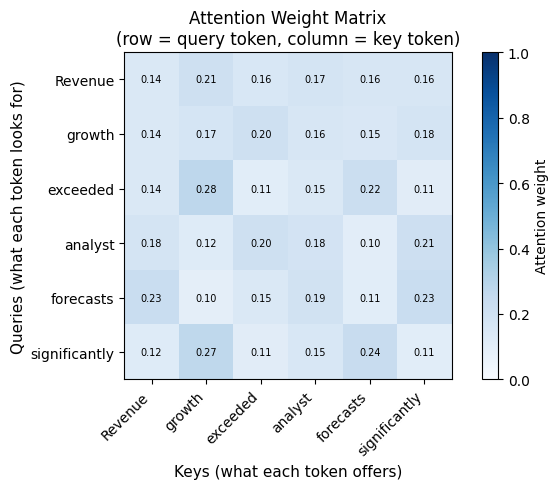

Each row is a probability distribution over keys.
In a trained model these patterns would reflect real linguistic relationships.


In [ ]:
token_labels = ["Revenue", "growth", "exceeded", "analyst", "forecasts", "significantly"]

torch.manual_seed(7)
tokens2 = torch.randn(1, len(token_labels), d_model)
W_Q2 = nn.Linear(d_model, d_k, bias=False)
W_K2 = nn.Linear(d_model, d_k, bias=False)
W_V2 = nn.Linear(d_model, d_k, bias=False)
_, attn_weights = scaled_dot_product_attention(W_Q2(tokens2), W_K2(tokens2), W_V2(tokens2))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(attn_weights[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(token_labels)))
ax.set_yticks(range(len(token_labels)))
ax.set_xticklabels(token_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(token_labels, fontsize=10)
ax.set_xlabel("Keys (what each token offers)", fontsize=11)
ax.set_ylabel("Queries (what each token looks for)", fontsize=11)
ax.set_title("Attention Weight Matrix\n(row = query token, column = key token)", fontsize=12)
plt.colorbar(im, ax=ax, label="Attention weight")
for i in range(len(token_labels)):
    for j in range(len(token_labels)):
        val = attn_weights[0, i, j].item()
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7,
                color='white' if val > 0.5 else 'black')
plt.tight_layout()
plt.show()
print("Each row is a probability distribution over keys (columns).")
print("In a trained model these patterns would reflect real linguistic relationships.")

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🧠
  </span>

**These Q, K, V weights are random** in our example. The pattern above is essentially arbitrary. In a trained transformer, the weight matrices are learned so that attention patterns capture meaningful relationships: subject-verb agreement, pronoun coreference, modifier-noun pairs, and so on. The visualization structure is identical to what you'd see in a real model — the values just become semantically meaningful.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>


# 13.2 Building Transformer Blocks and Model Architectures

<img alt="Transformers Soundwave" src="../images/L13_transformers_soundwave.png" width=900 style="display:block;">
<font size=2> Soundwave (who transforms into a cassette player and has a condor cassette) is the coolest transformer and one of the most iconic toys of the 80s</font>

With the attention mechanism in hand, this section assembles it into the full transformer architecture. We'll add multi-head attention (running attention multiple times in parallel to capture different kinds of relationships), then build a complete transformer block from components you've already seen throughout this course, and finally look at how the same building block is specialized into the major model families.

## Multi-Head Attention: Multiple Views of the Same Sequence

Running attention once gives one "view" of the relationships between tokens. But different kinds of relationships coexist in the same sentence:

- Token 3 might attend to token 1 because of a grammatical relationship (subject → verb)
- Token 3 might also attend to token 7 because of a semantic relationship (company → acquired)
- Token 3 might attend to the preceding token for local fluency reasons

**Multi-head attention** runs attention $H$ times in parallel, each with its own learned Q, K, V projections, then concatenates the results and projects them back to the model dimension:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_H)\, W^O$$

where $\text{head}_i = \text{Attention}(Q W_i^Q,\; K W_i^K,\; V W_i^V)$

**The four weight matrices.** Each head $i$ has three projection matrices:

| Symbol | Shape | Role |
|--------|-------|------|
| $W_i^Q$ | $d_{\text{model}} \times d_k$ | Projects the input into query space for head $i$ |
| $W_i^K$ | $d_{\text{model}} \times d_k$ | Projects the input into key space for head $i$ |
| $W_i^V$ | $d_{\text{model}} \times d_v$ | Projects the input into value space for head $i$ |
| $W^O$ | $(H \cdot d_v) \times d_{\text{model}}$ | Output projection - applied once, after all heads |

The only hard constraint is $H \times d_v = d_{\text{model}}$: each head produces a $d_v$-dimensional output, the $H$ outputs are concatenated to form an $H \cdot d_v = d_{\text{model}}$ vector, and $W^O$ projects that back to $d_{\text{model}}$. The query/key dimension $d_k$ is independent. It can in principle differ from $d_v$. In practice, the original paper and virtually all standard implementations (including PyTorch's `nn.MultiheadAttention`) use the simplifying convention $d_k = d_v = d_{\text{model}} / H$, but that is a design choice, not a mathematical requirement.

The final projection layer, $W^O$ is not just a reshape, it *mixes* information across heads, allowing the model to combine the different types of relationships each head has specialized in.

In PyTorch's `nn.MultiheadAttention`, the $W^Q$, $W^K$, $W^V$ matrices are fused into a single weight (`in_proj_weight`, shape $3 d_{\text{model}} \times d_{\text{model}}$) for efficiency, and $W^O$ is stored as `out_proj.weight` (shape $d_{\text{model}} \times d_{\text{model}}$).

Each head can specialize in capturing a different type of relationship. PyTorch provides this as a built-in module:


In [17]:
# d_model=64, num_heads=8 → each head operates on 64/8 = 8 dimensions
d_model = 64
num_heads = 8

mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)

# Simulate a batch of 2 sequences, each 10 tokens long, with 64-dim embeddings
x = torch.randn(2, 10, d_model)

# In self-attention, Q, K, and V all come from the same input x
attn_output, attn_weights = mha(x, x, x)
print(f"The input is a batch of {x.shape[0]} sequences, each with {x.shape[1]} tokens, each token a {x.shape[2]}-dimensional vector")
print(f"Input shape:   {x.shape}")
print()
print(f"The output has the same shape as the input, but each token's representation has been updated based\n on its relationships to all other tokens in the sequence, as determined by the attention mechanism:")
print(f"Output shape:  {attn_output.shape}   ← same shape as input")
print()
print(f"The weights represent the attention distributions for each token (query) over all tokens (keys).\n In a trained model, these would reflect meaningful relationships between tokens:")
print(f"Weight shape:  {attn_weights.shape}  ← (batch, seq_len, seq_len) averaged across heads")
print(f"\nTotal parameters: {sum(p.numel() for p in mha.parameters()):,}")
print(f"  → Four weight matrices: W_Q, W_K, W_V, W_O (each {d_model}×{d_model})")

The input is a batch of 2 sequences, each with 10 tokens, each token a 64-dimensional vector
Input shape:   torch.Size([2, 10, 64])

The output has the same shape as the input, but each token's representation has been updated based
 on its relationships to all other tokens in the sequence, as determined by the attention mechanism:
Output shape:  torch.Size([2, 10, 64])   ← same shape as input

The weights represent the attention distributions for each token (query) over all tokens (keys).
 In a trained model, these would reflect meaningful relationships between tokens:
Weight shape:  torch.Size([2, 10, 10])  ← (batch, seq_len, seq_len) averaged across heads

Total parameters: 16,640
  → Four weight matrices: W_Q, W_K, W_V, W_O (each 64×64)


In [25]:

# Inspect the four weight matrices inside nn.MultiheadAttention
print("Weight matrix shapes inside nn.MultiheadAttention (d_model=64, num_heads=8):")
print()
print(f"  in_proj_weight:   {mha.in_proj_weight.shape}  ← fused W_Q, W_K, W_V stacked vertically")
print(f"                     = 3 × d_model rows ({d_model}+{d_model}+{d_model}) × d_model cols")
print()
print(f"  out_proj.weight:  {mha.out_proj.weight.shape}  ← W^O: mixes info from concatenated heads, w/o changing dimension")
print()
print(f"Each head operates on d_model/num_heads = {d_model}/{num_heads} = {d_model//num_heads} dimensions")
print(f"Concatenating {num_heads} heads × {d_model//num_heads} dims = {d_model} dims")
print(f"Then W^O mixes the information from those multiheads together without changing the dimmension.")


Weight matrix shapes inside nn.MultiheadAttention (d_model=64, num_heads=8):

  in_proj_weight:   torch.Size([192, 64])  ← fused W_Q, W_K, W_V stacked vertically
                     = 3 × d_model rows (64+64+64) × d_model cols

  out_proj.weight:  torch.Size([64, 64])  ← W^O: mixes info from concatenated heads, w/o changing dimension

Each head operates on d_model/num_heads = 64/8 = 8 dimensions
Concatenating 8 heads × 8 dims = 64 dims
Then W^O mixes the information from those multiheads together without changing the dimmension.


## The Transformer Block

<img alt="Transformer Block" src="../images/L13_transformer_block.png" width="300" style="display:block;">

A single **transformer block** combines:

1. **Multi-head self-attention** — let every token attend to every other token
2. **Residual connection + LayerNorm** — add the input back in (you built this in Lecture 11) and normalize
3. **Position-wise feedforward network** — two linear layers with a ReLU nonlinearity, applied identically to each token position independently
4. **Another residual + LayerNorm** — the same pattern repeated

The feedforward sub-layer is what gives each token its own independent "thinking" step after the global communication of attention. A typical ratio is $d_{\text{ff}} = 4 \times d_{\text{model}}$.

**LayerNorm vs BatchNorm:** In Lecture 10 you saw BatchNorm, which normalizes across the batch dimension. For sequences, batch items can have different lengths, and normalization across a batch becomes inconsistent. LayerNorm normalizes across the feature dimension for each token independently — stable regardless of sequence length or batch size.

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

**Nothing here is new to you.** A transformer block is: linear layers, residual connections, normalization, and dropout. The *combination* and *scale* are what's new. The attention mechanism is the key insight. Why did they make such a splash? Because this particular combination unlocks the full potential (parallelized training, not sequential) and it was the first time anyone had put it together in a way that scales.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

In [28]:
class TransformerBlock(nn.Module):
    """
    One transformer encoder block:
        Multi-Head Self-Attention → Add & Norm → Feedforward → Add & Norm
    """
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Sub-layer 1: multi-head self-attention with residual connection
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))

        # Sub-layer 2: position-wise feedforward with residual connection
        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x

In [29]:
# Forward pass to verify shapes
block = TransformerBlock(d_model=64, num_heads=8, d_ff=256)

x = torch.randn(2, 10, 64)   # batch=2, seq_len=10, d_model=64
out = block(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}  ← shape preserved; blocks are freely stackable (remember residual connections?)")
print(f"\nParameters in one block: {sum(p.numel() for p in block.parameters()):,}")

Input shape:  torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])  ← shape preserved; blocks are freely stackable (remember residual connections?)

Parameters in one block: 49,984


In [30]:
# Stack N identical blocks into a complete encoder
class MiniTransformerEncoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff) for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

encoder = MiniTransformerEncoder(d_model=64, num_heads=8, d_ff=256, num_layers=6)
print(f"6-layer mini-encoder: {sum(p.numel() for p in encoder.parameters()):,} parameters")
print()
print("For reference:")
print("  BERT-base  → 12 layers, d_model=768,  ~110 million parameters")
print("  GPT-3      → 96 layers, d_model=12288, ~175 billion parameters")

6-layer mini-encoder: 299,904 parameters

For reference:
  BERT-base  → 12 layers, d_model=768,  ~110 million parameters
  GPT-3      → 96 layers, d_model=12288, ~175 billion parameters


## Encoder, Decoder, and Encoder-Decoder Architectures

<img alt="Encoder-only, decoder-only and encoder-decoder transformers" src="../images/L13_encoder_decoder_transformers.png" width="950" style="display:block;">

The original 2017 paper used a full encoder-decoder architecture for machine translation. Since then, the field has specialized into three families. The key difference between them is **which tokens each token is allowed to attend to**.

### Encoder-Only (e.g., BERT, DistilBERT)

In an encoder, every token can attend to **every other token in both directions** — left and right, past and future. Token 5 can look at token 1 *and* token 10 simultaneously. This is called **bidirectional attention**.

The result is a rich contextual representation of each token that "knows about" the entire surrounding sentence. This is ideal for tasks where you need to *understand* a complete piece of text — classification, named entity recognition, question answering. You read the whole sentence and then make a decision.

**Pre-training task**: Masked Language Modeling (MLM). Randomly mask 15% of tokens and train the model to predict them. Because predicting a masked token requires understanding both left and right context, the model is forced to build bidirectional representations.

### Decoder-Only (e.g., GPT-2/3/4, LLaMA, Mistral)

In a decoder, each token can only attend to **previous tokens** — never future ones. Token 5 can see tokens 1–4, but not tokens 6, 7, 8. This restriction is called **causal masking** (or autoregressive attention), and it's enforced by masking out the upper triangle of the attention weight matrix to $-\infty$ before the softmax.

Why the restriction? Because the decoder's job is *generation* — predicting the next token one at a time. During generation, future tokens simply don't exist yet, so it would be cheating to look at them during training. Causal masking makes training consistent with inference.

**Pre-training task**: Next-token prediction. Given tokens 1 through $t$, predict token $t+1$. Simple and scalable — every position in every sequence provides a training signal.

ChatGPT, Claude, and Gemini are all decoder-only architectures.

### Encoder-Decoder (e.g., T5, BART)

This architecture uses *both* components. The **encoder** reads the full input with bidirectional attention, building a rich understanding of it. The **decoder** then generates the output one token at a time with causal attention — but it also has a second attention mechanism called **cross-attention** that lets each decoder token attend to the encoder's output. This is how the decoder "reads" the input while generating a response.

The information flow is:
1. Encoder processes the *source* (e.g., a French sentence) with full bidirectional attention → produces a sequence of context vectors
2. Decoder generates the *target* (e.g., English translation) token by token, attending to previous decoder tokens (causal) and to the encoder output (cross-attention)

This is ideal for **sequence-to-sequence** tasks where input and output are both sequences of potentially different lengths: translation, summarization, question answering with a generated answer.

---

| Architecture | Key Models | Attention | Pre-training Task | Best For |
|---|---|---|---|---|
| **Encoder-only** | BERT, RoBERTa, DistilBERT | Bidirectional | Masked Language Modeling | Understanding: classification, NER, QA |
| **Decoder-only** | GPT-2/3/4, LLaMA, Mistral | Causal (left-to-right only) | Next-token prediction | Generation: completion, dialogue, code |
| **Encoder-Decoder** | T5, BART | Encoder: bidirectional; Decoder: causal + cross-attention | Denoising / seq2seq | Seq2seq: translation, summarization |

The HuggingFace models we'll use in sections 13.3 and 13.4 are encoder-only (DistilBERT), which is optimal for classification tasks because we need to understand a complete input before assigning a label.


# 13.3 The HuggingFace Ecosystem and the `pipeline()` API

<img alt="Aliens facehugger" src="../images/L13_aliens_facehugger.png" width=900 style="display:block;">
<font size=2> Ripley having a rough time with facehuggers in <i>Aliens (1986)</i></font>

HuggingFace started as a company building conversational AI, then open-sourced the `transformers` library in 2019. It has since become the de facto center of gravity for sharing, discovering, and deploying pretrained models — essentially the GitHub of machine learning models. This section covers the Hub itself and the `pipeline()` API, which lets you put a state-of-the-art model to work in three lines of code.

## The HuggingFace Hub

[Huggingface](https://huggingface.co/) contains:
- **500,000+ models** from individual researchers, academic labs, and major companies (Meta, Google, Mistral, Stability AI, and many more)
- **Model cards** for each model: architecture, training data, intended use, known limitations, benchmark results, and license
- **Datasets library**: 100,000+ datasets ready to load in one line
- **Spaces**: hosted demos you can try in the browser before downloading anything

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🧠
  </span>

The key insight for practitioners: the gap between a research paper and running code has collapsed. A model that achieves state-of-the-art on a benchmark is often available on the Hub within days of the paper — and you can download and run it with three lines of code. The question for your organization shifts from *"how do we build this?"* to *"which pretrained model do we start from, and how much fine-tuning do we need?"* That is a much more tractable question for most business analytics teams.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Sentiment Analysis on Customer Reviews

The `pipeline()` function is HuggingFace's highest-level API. It handles model loading, tokenization, inference, and post-processing behind a single consistent interface. Let's start with the most common business NLP task.

> **Note**: The first time you run each pipeline, it downloads a model from HuggingFace (~250–500 MB). Subsequent runs use the local cache. Ensure you have an internet connection.

In [ ]:
from transformers import pipeline

# Default model: distilbert-base-uncased-finetuned-sst-2-english (~250 MB)
sentiment_pipe = pipeline("sentiment-analysis")

customer_reviews = [
    "The onboarding process was seamless and the account manager was incredibly helpful.",
    "Waited three weeks for a resolution and it still isn't fixed. Completely unacceptable.",
    "Product is fine. Does what it says. Nothing remarkable but no complaints.",
    "I've been a customer for five years and the quality has really gone downhill lately.",
    "Honestly surprised by how fast shipping was — arrived two days early!",
]

print("Sentiment Analysis Results")
print("=" * 65)
results = sentiment_pipe(customer_reviews)
for review, result in zip(customer_reviews, results):
    label = result['label']
    score = result['score']
    indicator = "🟢" if label == "POSITIVE" else "🔴"
    print(f"{indicator} {label:8} ({score:.1%})  |  {review[:55]}...")

## Zero-Shot Classification: No Labels Required

Zero-shot classification lets you assign text to any categories you define **without any labeled training data and without retraining the model**. Under the hood it uses a Natural Language Inference (NLI) model to check whether a hypothesis like *"This example is about [label]"* is entailed by the input text.

This is enormously practical: you can prototype a text routing or classification system in minutes, validate that it's conceptually workable, and *then* decide whether to invest in labeled data and fine-tuning. It's often the right first attempt.

In [ ]:
zsc_pipe = pipeline("zero-shot-classification")

customer_emails = [
    "My invoice shows a charge of $299 that I never authorized. Please fix this immediately.",
    "The screen on my laptop is flickering and sometimes goes completely black.",
    "I'd like to upgrade my current plan to include the enterprise analytics add-on.",
    "Just wanted to say — your product has genuinely changed how our team works. Thank you.",
    "My package was marked delivered but I never received it. This is the second time.",
]

# These categories are defined by us — the model was never trained on these labels
departments = ["Billing & Payments", "Technical Support", "Sales & Upgrades",
                "Customer Feedback", "Shipping & Logistics"]

print("Zero-Shot Classification: Customer Email Routing")
print("=" * 70)
for email in customer_emails:
    result = zsc_pipe(email, candidate_labels=departments)
    print(f"\nEmail:    {email[:65]}...")
    print(f"  → Route to: {result['labels'][0]} ({result['scores'][0]:.1%})")
    print(f"     Runner-up: {result['labels'][1]} ({result['scores'][1]:.1%})")

In [ ]:
# The labels are just strings we supply — change them completely and the model adapts instantly
# No retraining, no labeled data, no code changes other than the label list itself
urgency_labels = ["High Priority", "Medium Priority", "Low Priority"]

print("Same Emails, Different Labels: Urgency Classification")
print("=" * 70)
for email in customer_emails:
    result = zsc_pipe(email, candidate_labels=urgency_labels)
    print(f"  {result['labels'][0]:18} ({result['scores'][0]:.1%})  |  {email[:55]}...")

## Named Entity Recognition

Named Entity Recognition (NER) identifies and classifies named entities in text (people, organizations, locations, dates, monetary amounts, and more). This is extremely useful for extracting structured information from unstructured documents: contracts, press releases, earnings calls, regulatory filings. Where sentiment analysis tells you how someone feels, NER tells you *about what* and *involving whom*.

In [ ]:
ner_pipe = pipeline("ner", aggregation_strategy="simple")

press_release = """
Meridian Capital Group announced today that its CEO, Sarah Chen, has signed a definitive 
agreement to acquire DataVault Technologies, Inc. for approximately $1.4 billion in cash. 
DataVault, headquartered in Austin, Texas, provides cloud-based data governance software 
to Fortune 500 companies. The transaction is expected to close by Q2 2026, subject to 
approval from the Federal Trade Commission and relevant European Union regulatory bodies.
Sarah Chen commented: "This acquisition accelerates our strategy to become the leading 
data infrastructure platform in North America."
"""

entities = ner_pipe(press_release)

print("Named Entities Extracted from Press Release")
print("=" * 60)

from collections import defaultdict
by_type = defaultdict(list)
for e in entities:
    by_type[e['entity_group']].append(e['word'])

for entity_type, words in sorted(by_type.items()):
    seen = set()
    unique_words = [w for w in words if not (w in seen or seen.add(w))]
    print(f"  {entity_type:12}: {', '.join(unique_words)}")

# 13.4 Fine-Tuning Pretrained Models for Business Tasks

The `pipeline()` API is great for quick prototyping. When you need to adapt a pretrained model to your specific problem (your labels, your domain vocabulary, your data), you work with `AutoModelForSequenceClassification` directly and fine-tune using the same workflow patterns you've been applying since Lecture 9. This section covers loading and inspecting a model, tokenization, three fine-tuning strategies, and the HuggingFace `Trainer` API.

## The Connection to Lab 3

This is the **same pattern you used in Lab 3 Part B**, just applied to text instead of images:

| Lab 3 Part B (Images) | HuggingFace Text Classification |
|---|---|
| Frozen ResNet18 backbone | Pretrained DistilBERT backbone |
| Strip `model.fc` to expose feature vectors | Load with `num_labels=N` to replace the classification head |
| Train the fusion head on movie genre labels | Fine-tune the classification head on your task labels |
| Optionally unfreeze `layer4` (stretch goal) | Optionally unfreeze top transformer layers |

The only difference is modality and the size of the pretrained model.

## Loading and Inspecting a Pretrained Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# A model already fine-tuned for sentiment — this is what pipeline() uses under the hood
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print(f"Model: {model_name}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Labels: {model.config.id2label}")

In [ ]:
# Tokenization: converting text into the integers the model processes
texts = [
    "This product exceeded every expectation.",
    "The worst customer service I have ever experienced.",
]

inputs = tokenizer(
    texts,
    return_tensors="pt",     # return PyTorch tensors
    padding=True,            # pad shorter sequences to the length of the longest
    truncation=True,
    max_length=128,
)

print("Tokenizer output keys:", list(inputs.keys()))
print(f"\ninput_ids shape:      {inputs['input_ids'].shape}   ← (batch_size, seq_len)")
print(f"attention_mask shape: {inputs['attention_mask'].shape}")
print(f"\nTokens for first sentence:")
print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]))
print()
print("Notice [CLS] at the start and [SEP] at the end — BERT-style special tokens.")
print("The [CLS] token's output is what the classification head reads from.")

In [ ]:
# Run inference manually — this is exactly what pipeline() does under the hood
model.eval()
with torch.no_grad():
    outputs = model(**inputs)       # ** unpacks the dict as keyword arguments
    logits = outputs.logits         # raw scores, shape (batch_size, num_labels)
    probs = torch.softmax(logits, dim=-1)
    predictions = torch.argmax(probs, dim=-1)

print("Manual Inference Results")
print("=" * 55)
for text, pred, prob_row in zip(texts, predictions, probs):
    label = model.config.id2label[pred.item()]
    confidence = prob_row[pred].item()
    print(f"Text:   {text}")
    print(f"  → {label} ({confidence:.1%})\n")

## Adapting to a Custom Classification Task

What if you have a different problem, e.g., routing customer support tickets into five internal departments? Load the same pretrained backbone but replace the head with one that has your number of output classes. The backbone's language understanding transfers; only the output layer needs training from scratch.

In [ ]:
CATEGORIES = ["Billing", "Technical Support", "Shipping", "Returns", "General Inquiry"]
NUM_LABELS = len(CATEGORIES)

# distilbert-base-uncased (no fine-tuning suffix) → base model with a fresh classification head
base_model_name = "distilbert-base-uncased"
tokenizer_custom = AutoTokenizer.from_pretrained(base_model_name)
model_custom = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=NUM_LABELS,
    id2label={i: cat for i, cat in enumerate(CATEGORIES)},
    label2id={cat: i for i, cat in enumerate(CATEGORIES)},
)

total_params    = sum(p.numel() for p in model_custom.parameters())
head_params     = sum(p.numel() for p in model_custom.classifier.parameters())
backbone_params = total_params - head_params

print(f"Custom {NUM_LABELS}-class ticket routing model")
print(f"  Total:    {total_params:>10,}")
print(f"  Backbone: {backbone_params:>10,}  ← pretrained, can be frozen")
print(f"  Head:     {head_params:>10,}  ← randomly initialized, needs training")
print(f"\nThe head is {head_params/total_params:.2%} of total parameters.")
print("Fine-tuning just the head on a small labeled dataset is often enough to start.")

## Three Fine-Tuning Strategies

### Strategy 1: Frozen Backbone + New Head

Freeze all pretrained weights. Only train the classification head.

- **When**: Small labeled dataset (hundreds to a few thousand examples); task is similar to pretraining domain
- **Pros**: Fast training, minimal data requirement, no risk of catastrophic forgetting
- **Cons**: Backbone representations can't adapt to domain-specific language

In [ ]:
# Freeze everything except the classification head
for name, param in model_custom.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_custom.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model_custom.parameters() if not p.requires_grad)
print(f"Strategy 1 — Frozen backbone:")
print(f"  Trainable: {trainable:>10,}  ({trainable/(trainable+frozen):.2%} of total)")
print(f"  Frozen:    {frozen:>10,}")

### Strategy 2: Full Fine-Tuning

Unfreeze and train all parameters end-to-end with a small learning rate.

- **When**: Thousands+ of labeled examples; domain language differs noticeably from general web text
- **Pros**: Maximum adaptability; backbone can shift to your domain vocabulary and writing style
- **Cons**: Slower; more data required; risk of catastrophic forgetting if the learning rate is too high

In [ ]:
# Unfreeze everything
for param in model_custom.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_custom.parameters() if p.requires_grad)
print(f"Strategy 2 — Full fine-tuning:")
print(f"  Trainable: {trainable:>10,}  (100% of total)")
print()
print("Typical learning rates for full fine-tuning: 1e-5 to 3e-5")
print("Use a warmup schedule and weight decay to stabilize training.")

### Strategy 3: Gradual Unfreezing

Start with the backbone frozen (strategy 1), let the head converge, then selectively unfreeze the top transformer layers and continue training at a lower learning rate. This mirrors the Lab 3 stretch goal of unfreezing `layer4` of ResNet after the fusion head stabilized.

- **When**: Medium-sized dataset; you want the benefits of both strategies above
- **Typical workflow**: Phase 1 (frozen, 3–5 epochs) → Phase 2 (head + top 1–2 layers, lower LR) → Phase 3 (unfreeze more if val accuracy plateaus)

In [ ]:
# Freeze backbone, unfreeze head + last transformer layer
for param in model_custom.parameters():
    param.requires_grad = False
for param in model_custom.classifier.parameters():
    param.requires_grad = True
for param in model_custom.distilbert.transformer.layer[5].parameters():  # last of 6 layers
    param.requires_grad = True

trainable = sum(p.numel() for p in model_custom.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model_custom.parameters() if not p.requires_grad)
print(f"Strategy 3 — Gradual unfreezing (head + top transformer layer):")
print(f"  Trainable: {trainable:>10,}  ({trainable/(trainable+frozen):.2%} of total)")
print(f"  Frozen:    {frozen:>10,}")

## The Trainer API

Writing your own training loop (as you've done throughout this course) gives you full control and is excellent for learning. In production, HuggingFace's `Trainer` API handles the loop — including evaluation, checkpointing, logging, early stopping, and distributed training — behind a clean interface.

In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np

# 1. Training arguments — analogous to your optimizer + hyperparameter variables
training_args = TrainingArguments(
    output_dir="./ticket_classifier",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,                  # small LR — pretrained weights are already good
    warmup_ratio=0.1,                    # ramp up LR over first 10% of training
    weight_decay=0.01,                   # L2 regularization
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,         # ≈ your early-stopping + checkpoint restore pattern
    metric_for_best_model="eval_loss",
    logging_dir="./logs",
    report_to="none",
)

# 2. Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": (predictions == labels).mean()}

# 3. Trainer (code-commented — no labeled data in this notebook)
# trainer = Trainer(
#     model=model_custom,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics,
# )
# trainer.train()
# results = trainer.evaluate(test_dataset)

print("Trainer API vs your manual training loop:")
print()
print("  TrainingArguments      ≈  optimizer config + hyperparameter variables")
print("  Trainer.train()        ≈  for epoch in range(N): ...")
print("  load_best_model_at_end ≈  your early-stopping + best checkpoint restore")
print("  compute_metrics        ≈  your accuracy/loss evaluation block")
print()
print("The logic is identical. Trainer handles boilerplate so you focus on the model.")

## Beyond Classification

The same HuggingFace ecosystem covers a wide range of tasks beyond text classification. Here's a map of the most practically relevant ones for business analytics:

| Task | HuggingFace Class / Pipeline | Representative Business Use Case |
|------|------------------------------|----------------------------------|
| Text classification | `AutoModelForSequenceClassification` | Sentiment, spam, topic routing, intent detection |
| Token classification (NER) | `AutoModelForTokenClassification` | Extract entities from contracts, emails, news |
| Extractive QA | `AutoModelForQuestionAnswering` | "What is the termination clause?" over a contract |
| Summarization | `AutoModelForSeq2SeqLM` | Condense earnings calls, reports, feedback threads |
| Translation | `AutoModelForSeq2SeqLM` | Multilingual customer support, international expansion |
| Zero-shot classification | `pipeline("zero-shot-classification")` | Custom categories, zero labeled data |
| Embeddings / semantic search | `sentence-transformers` | Semantic search, deduplication, clustering |
| Speech-to-text | `AutoModelForSpeechSeq2Seq` (Whisper) | Transcribe calls, meetings, voicemails |
| Image classification (SOTA) | `AutoModelForImageClassification` | Vision Transformer (ViT) - Lab 3 with a transformer backbone |

**Zero-shot classification** is often the right *first* attempt before committing to labeled data. Try it. If accuracy is sufficient, you're done. If not, you now have a realistic accuracy ceiling and can decide how much labeling investment to make.

**Vision Transformer (ViT)** closes the arc of this course. In Lab 3 you fine-tuned a frozen ResNet18 backbone. A ViT does the same thing: divides the image into 16×16 patches, treats each patch as a token, runs a standard transformer encoder over them. It is fine-tuned with the identical workflow you just learned.

In [ ]:
print("Vision Transformer (ViT) — google/vit-base-patch16-224")
print()
print("Input:   224×224 image")
print("Step 1:  Divide into 14×14 = 196 patches of size 16×16 pixels")
print("Step 2:  Linearly project each patch to a 768-dim vector (the 'token')")
print("Step 3:  Prepend [CLS] token, add positional encodings → 197-token sequence")
print("Step 4:  Run through 12 transformer encoder blocks")
print("Step 5:  Take [CLS] output → classification head")
print()
print("It's a BERT encoder applied to image patches instead of word tokens.")
print("Fine-tuning API: identical to everything you just did for text.")
print()
print("Usage:")
print("  from transformers import AutoFeatureExtractor, AutoModelForImageClassification")
print("  extractor = AutoFeatureExtractor.from_pretrained('google/vit-base-patch16-224')")
print("  model = AutoModelForImageClassification.from_pretrained('google/vit-base-patch16-224')")
print("  inputs = extractor(images=[pil_image], return_tensors='pt')")
print("  logits = model(**inputs).logits")

<!-- Start Exercise 13.1 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 13.1: Zero-Shot Classification Explorer</font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Zero-shot classification doesn't require any training data, which makes it a powerful tool for quickly prototyping classification systems. In this exercise, you'll experiment with it to build intuition about what it can (and can't) do.

**Your task:**
1. Come up with 3–5 short sentences or short paragraphs of text relevant to a business domain you care about (customer emails, product reviews, news headlines, job postings, etc).
2. Run zero-shot classification with **two different sets of candidate labels** on the same texts.
3. Observe: In which cases did the model perform well? Where did it struggle? What does this tell you about when you'd trust zero-shot vs. when you'd invest in labeled data?
</div>

In [ ]:
# Exercise 13.1 — Your code here
from transformers import pipeline

zsc = pipeline("zero-shot-classification")  # We'll use zero-shot-classifier, but look over the args for pipeline to see all the other options!

# Step 1: Write your own texts (replace these examples)
my_texts = [
    "I have been double charged on my last invoice.",
    "The software crashes every time I try to export a PDF.",
    "Can I add two more user licenses to my account?",
]

# Step 2: Your first set of candidate labels
labels_v1 = ["Billing", "Technical Support", "Sales", "General Inquiry"]

print("Label set 1:", labels_v1)
print("=" * 60)
for text in my_texts:
    result = zsc(text, candidate_labels=labels_v1)
    print(f"  {result['labels'][0]} ({result['scores'][0]:.1%})  |  {text}")
print()

# Step 3: A completely different set of labels on the same texts
labels_v2 = ["Urgent", "Non-urgent"]

print("Label set 2:", labels_v2)
print("=" * 60)
for text in my_texts:
    result = zsc(text, candidate_labels=labels_v2)
    print(f"  {result['labels'][0]} ({result['scores'][0]:.1%})  |  {text}")

<hr  />
<!-- End Exercise 13.1 -->

## Summary

This lecture traced the path from the attention mechanism (a single matrix operation) to the transformer architecture, and then to applying state-of-the-art pretrained models to real business problems using HuggingFace.

### Key Takeaways

**Self-Attention and the Attention Formula**:
- CNNs capture local patterns; text and other sequential data require long-range relationships that locality can't model
- Attention lets every position directly attend to every other position in a single operation: $\text{softmax}(QK^T / \sqrt{d_k})V$
- Q, K, V are learned linear projections — just weight matrices trained by gradient descent like any other parameter

**Multi-Head Attention**:
- Running attention $H$ times in parallel lets different heads specialize in different relationship types (syntactic, semantic, positional)
- Four weight matrices per layer: $W_i^Q$, $W_i^K$, $W_i^V$ (one set per head), and a single $W^O$ that mixes head outputs back to $d_{\text{model}}$
- The convention $d_k = d_v = d_{\text{model}} / H$ is standard but not mathematically required; the hard constraint is $H \times d_v = d_{\text{model}}$

**Transformer Blocks and Architectures**:
- One block = multi-head attention + residual + LayerNorm + feedforward + residual + LayerNorm; no new building blocks beyond what you've already learned
- Three architecture families: encoder-only (bidirectional attention, best for understanding), decoder-only (causal attention, best for generation), encoder-decoder (both, best for seq2seq)
- Transformers replaced RNNs primarily because attention is fully parallelizable across the sequence; no sequential dependency between positions

**HuggingFace `pipeline()` API**:
- `pipeline("task")` wraps model loading, tokenization, inference, and post-processing in one call
- Sentiment analysis, zero-shot classification, and NER are immediately applicable to business text with little or no labeled data
- Zero-shot classification is often the right first attempt: no training data, no code changes, just define your label strings

**Fine-Tuning Pretrained Models**:
- The pattern is identical to Lab 3: pretrained backbone + fresh classification head; choose how much to unfreeze based on dataset size
- Three strategies: frozen backbone (small data), full fine-tuning (large data), gradual unfreezing (medium data)
- `AutoModelForSequenceClassification` loads any backbone with a new head sized to your number of classes
- HuggingFace `Trainer` wraps the training loop you've been writing since Lecture 9 (same logic, less boilerplate)

### The Arc of This Course

You started by building a single artificial neuron from scratch. You learned gradient descent, backpropagation, and what makes networks learn. You built training loops, added dropout and regularization, implemented residual connections, trained CNNs on images, and fine-tuned a pretrained backbone in Lab 3.

Today's transformer is built from exactly those components: linear layers, residual connections, normalization, and gradient descent. The scale is different. The architecture is elegant. But the fundamentals are the same ones you've been working with all semester.

The field will keep evolving: new architectures, new benchmarks, new capabilities. The conceptual foundation you've built in this course is what lets you keep up with it.


## Extended Learning Resources

- **[Visualizing Transformers and Attention](https://youtu.be/KJtZARuO3JY)** by 3blue1brown: A great (and slightly less animation heavy) visualization of how transformers work.
- **[The Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/)** by Jay Alammar: A great visual walkthrough of the architecture. Read it!
- **[Attention Is All You Need](https://arxiv.org/abs/1706.03762)**:  the original 2017 paper. Shorter than you'd expect; the architecture diagram on page 3 is worth looking at once.
- **[HuggingFace NLP Course](https://huggingface.co/learn/nlp-course/chapter1/1)**:  free, excellent, goes much deeper on fine-tuning, tokenization, and the Trainer API than we covered.
- **[Andrej Karpathy: Let's Build GPT from Scratch](https://www.youtube.com/watch?v=kCc8FmEb1nY)**:  2 hours building a character-level GPT in pure PyTorch. If attention clicked today and you want to get more in the weeds, this is the next step.


## Reflection Questions

*Take a few minutes to write your thoughts*

1. **Explain how transformers work to a 5-year old** What would you say? How would you distill their complexity into a description that's just complicated enough to capture the spirit of transformers?

2. **Zero-shot classification** requires no labeled training data. What are the implications for how organizations should think about building text classification systems? When is it worth investing in labeled data?

3. **How might you use SoTa models from huggingface in your work?** Browse [huggingface spaces](https://huggingface.co/spaces). How might you leverage the SoTA models there for use in your own work, company or idea? What data would you need?

4. **Your questions on transfomers/huggingface**: What didn't make sense? What do you want to understand better?

5. **The course arc**: This course was a combination of programming concepts, advanced ML methods and neural networks. Thinking over its structure (now that you've seen it all). What was the good? What was the bad? What should there be more of / less of? You've eaten my dog food, now tell me how to make it better.

**Your reflection:**

[Write your thoughts here]
